In [96]:
import os 
import warnings
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import shutil 
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [97]:
tf.random.set_seed(42)
np.random.seed(42)

In [98]:
LOCAL_DATASET_PATH = r"E:\Mohamed\vs code projects\AI porjects\final project M\COVID19_Cleaned_Dataset"


In [99]:
raw_cat = [
    d for d in os.listdir(os.path.join(LOCAL_DATASET_PATH))
    if os.path.isdir(os.path.join(LOCAL_DATASET_PATH,d))
]
print(f"Catogires is: {raw_cat}")

Catogires is: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [100]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [101]:
filepaths = []
lables = []

for category in os.listdir(LOCAL_DATASET_PATH):
    cat_dir = os.path.join(LOCAL_DATASET_PATH,category)

    if os.path.isdir(cat_dir):
        for img_name in os.listdir(cat_dir):
            if img_name.lower().endswith(('.png','.jpg','.jpeg')):
                filepaths.append(os.path.join(cat_dir,img_name))
                lables.append(category)


df = pd.DataFrame({'filename':filepaths,'class':lables})


In [102]:
train_df , val_test_df = train_test_split (df , test_size=0.2,random_state= 42 , stratify=df['class'])
valid_df , test_df = train_test_split(val_test_df , test_size= 0.5 , random_state= 42 , stratify=val_test_df['class'])

print(f"train sample: {len(train_df)}")

print(f"test sample: {len(test_df)}")

print(f"validation sample: {len(valid_df)}")

train sample: 16932
test sample: 2117
validation sample: 2116


In [103]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 15,
    width_shift_range = 0.08,  
    height_shift_range = 0.08,
    shear_range  = 0.08,
    zoom_range = 0.1,
    horizontal_flip = True,
    fill_mode='nearest'
)


val_and_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = preprocess_input
)

In [104]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True
)

test_gen = val_and_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

valid_gen = val_and_test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filename',
    y_col='class',
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

Found 16932 validated image filenames belonging to 4 classes.
Found 2117 validated image filenames belonging to 4 classes.
Found 2116 validated image filenames belonging to 4 classes.


In [105]:
train_classes = train_gen.classes

class_weights_arr = compute_class_weight(
    class_weight= 'balanced',
    classes= np.unique(train_classes),
    y= train_classes
)

class_weight_dict = dict(enumerate(class_weights_arr))
 

In [110]:
base_model = DenseNet121 (weights='imagenet', include_top=False , input_shape=(224,224,3)) 
base_model.trainable = False

model = models.Sequential([
    base_model, 
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4,activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics = ['accuracy',
               tf.keras.metrics.Precision(name='precision'),
               tf.keras.metrics.Recall(name='recall')]
)

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,316 (27.36 MB)

 Trainable params: 133,764 (522.52 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [112]:
callbacks_ph1 = [
    callbacks.EarlyStopping(monitor='val_loss',
                            patience= 5,
                            restore_best_weights= True,
                            verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss',
                                factor = 0.2,
                                patience = 2,
                                min_rlu=1e-5,
                                verbose=1)
]

In [ ]:
ph1 = model.fit(
    train_gen,
    epochs = 20,
    validation_data = valid_gen,
    callbacks = callbacks_ph1,
    class_weight = class_weight_dict
    
)

Epoch 1/20
105/530 ━━━━━━━━━━━━━━━━━━━━ 15:43 2s/step - accuracy: 0.6699 - loss: 0.7674 - precision: 0.7017 - recall: 0.6307

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks_ph2 = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience= 7,
        restore_best_weights= True
    ),
    callbacks.ModelCheckpoint(
        'best_densenet_chest.keras',
        monitor='val_accuracy',
        save_best_only= True
    )
]

In [ ]:
ph2 = model.fit(
    train_gen,
    epochs = 25,
    validation_data = valid_gen,
    callbacks=callbacks_ph2
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.8646 - loss: 0.3369 - val_accuracy: 0.8333 - val_loss: 0.5086
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.8777 - loss: 0.3101 - val_accuracy: 0.8472 - val_loss: 0.5036
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.8630 - loss: 0.3592 - val_accuracy: 0.8333 - val_loss: 0.5021
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.8809 - loss: 0.3342 - val_accuracy: 0.8333 - val_loss: 0.5005
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8891 - loss: 0.3168 - val_accuracy: 0.8333 - val_loss: 0.4943
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8744 - loss: 0.3044 - val_accuracy: 0.8333 - val_loss: 0.4939
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.8418 - loss: 0.4003 - val_accuracy: 0.8333 - val_loss: 0.4928
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.8679 - loss: 0.3260 - val_accuracy: 0.8333 - val_loss


📊 Evaluating DenseNet121 on Test Set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.7238 - loss: 0.7033
Test Loss: 0.7033
Test Accuracy: 0.7238
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma       0.88      0.47      0.61       120
   large.cell.carcinoma       0.47      0.90      0.62        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.73      0.81      0.77        90

               accuracy                           0.72       315
              macro avg       0.77      0.79      0.75       315
           weighted avg       0.79      0.72      0.72       315



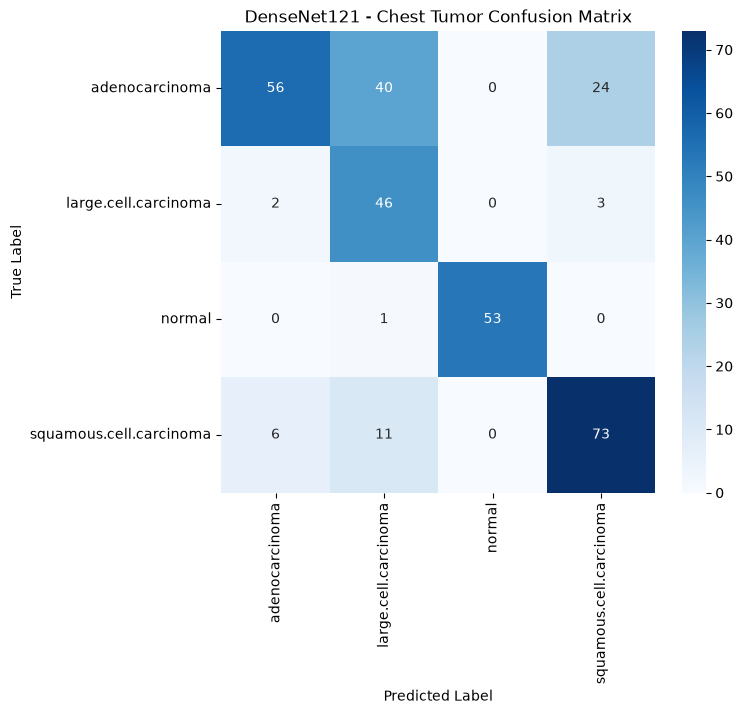

In [ ]:
print("\n📊 Evaluating DenseNet121 on Test Set...")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_gen)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions & Evaluation Metrics
y_pred_probs = model.predict(test_gen)


y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DenseNet121 - Chest Tumor Confusion Matrix')
plt.show()